In [1]:
import numpy as np
import matplotlib.pyplot as plt
import kwant

from scipy.constants import physical_constants

In [2]:
a = 0.5 * 10**(-9)
a_nm = a*10**9
N = 161
L = (N+1)*a
L_nm = (N+1)*a_nm
print("N=", N)
print("L=",L,"m")
print("L_nm=",L_nm,"nm")
print("a_nm=",a_nm,"nm")

N= 161
L= 8.100000000000001e-08 m
L_nm= 81.0 nm
a_nm= 0.5 nm


In [3]:
h_bar = physical_constants['Planck constant over 2 pi'][0]
eV_unit = physical_constants['electron volt'][0]
m_el = physical_constants['electron mass'][0]
el_charge = physical_constants['elementary charge'][0]  
k_B = physical_constants['Boltzmann constant'][0] 
k_B_eV = k_B/eV_unit
h_bar_eV = h_bar/eV_unit

In [4]:
m_ef = 0.067 * m_el
t = (h_bar**2) / (2*m_ef*a**2)
t = t / eV_unit
print("t=",t)

t= 2.2746161126268385


In [5]:
sys = kwant.Builder()
lat = kwant.lattice.chain(a_nm)

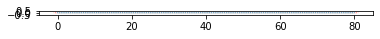

In [6]:
def onsite(site, x0, x1, W0, U0, V):
    (x,) = site.pos
    if x >= x0 - W0/2 and x <= x0 + W0/2  or x >= x1 - W0/2 and x <= x1 + W0/2:
        return 2*t + U0 - V * x / L_nm
    else:
        return 2*t - V * x / L_nm
    
def onsite_lead(site, V):
    (x,) = site.pos
    return 2*t - V
    

for i in range(N):
    sys[lat(i)] = onsite
    
sys[lat.neighbors()] = -t

leadl = kwant.Builder(kwant.TranslationalSymmetry((-a_nm,)))
leadl[lat(0)] = 2*t
leadl[lat.neighbors()] = -t

leadr = kwant.Builder(kwant.TranslationalSymmetry((a_nm,)))
leadr[lat(0)] = onsite_lead
leadr[lat.neighbors()] = -t

leadr = leadl.reversed()

sys.attach_lead(leadl)
sys.attach_lead(leadr)

kwant.plot(sys);

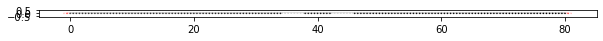

In [11]:
sysf = sys.finalized()
Vp = 0.1
U0p = 0.35
x0p = 36
x1p = 44
W0p = 3
kwant.plot(sysf, site_color=lambda \
           site:sysf.hamiltonian(site, site, params=dict(U0=U0p, x0=x0p, x1=x1p, W0=W0p, V=Vp)), fig_size=(10,10), colorbar=False);

In [12]:
def calc_T(sysf, E, U0, x0, x1, W0, V):
    smatrix = kwant.smatrix(sysf, E, params=dict(U0=U0, x0=x0, x1=x1, W0=W0, V=V))
    return smatrix.transmission(1, 0) 

In [13]:
Emin = 0.0001
Emax = 2*U0p
NE = 100

Vp = 0.1
U0p = 0.35
x0p = 36
x1p = 44
W0p = 3

Etab = np.linspace(Emin, Emax, NE)
Ttab_p = np.zeros(NE)



Ttab_pp = np.zeros(NE)

for i in range(NE):
    Ttab_p[i] = calc_T(sysf, Etab[i], U0p, x0p, x1p, W0p, Vp)
    


U0p= 0.35


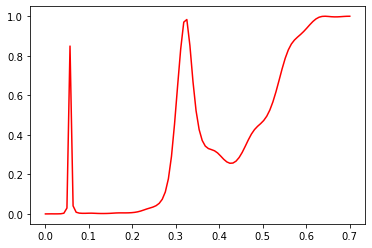

In [16]:
print("U0p=",U0p)
plt.plot(Etab, Ttab_p , "r");

In [15]:
from ipywidgets import interact


def plot_wf(i=1):
    wf = kwant.solvers.default.wave_function(sysf, Etab[i], params=dict(U0=U0p,x0=x0p,x1=x1p,W0=W0p, V=Vp));
    
    print("E=",Etab[i])
    norm=np.sum(np.abs(wf(0)[:])**2)

    
    plt.subplot(1, 2, 1)
    plt.plot((np.abs(wf(0)[0]))**2/norm); 
    plt.xlabel('x')
    plt.ylabel('$|\Psi|^2$')
    plt.grid()
    
    plt.subplot(1, 2, 2)
    plt.plot(Etab,Ttab_p)
    plt.xlabel('E')
    plt.ylabel('T')
    plt.grid()
    plt.axvline(x = Etab[i], color = 'tab:red', label = 'axvline - full height')
    plt.tight_layout()
    plt.show()
       
    
interact(plot_wf, i=(0,NE));

interactive(children=(IntSlider(value=1, description='i'), Output()), _dom_classes=('widget-interact',))

In [24]:
T = 293 %%!
bet = 1/(k_B_eV*T)
C = el_charge*m_ef*k_B_eV*T/( 2*np.pi**2*h_bar_eV**3 )*6.242*10**14

def fs_funk(ene, mul, mur, bet):
    return np.log( ( np.exp(-bet*(ene-mul))+1 )/( np.exp(-bet*(ene-mur))+1 ) )

SyntaxError: invalid syntax (2969602371.py, line 1)

In [26]:
# Dealing with current
Emin = 0.0001
Emax = 0.16
NE = 100
dE = Etab[1] - Etab[0]
Etab = np.linspace(Emin, Emax, NE)
# Determine Fermi energies/chemical potentials
Vp = 0.1
mu = 0.05
mul = mu
mur = mu - Vp
NV = 20
Vmin = 0.0
Vmax = 0.3
Vtab = np.linspace(Vmin, Vmax, NE)
Itab = np.zeros(NV



Integral = 0.0
for j n range(NV):
    Vp = Vtab[j]
    mul = mu
    mur = mu - Vp
    for i in range(NE):
        Ttab_p[i] = calc_T(sysf, Etab[i], U0p, x0p, x1p, W0p, Vp)
        Itab[j] = Itab[j] + Ttab_p[i] * fs_funk(Etab[i], mul, mur, bet
    print(Integral)
                                                
#ntegral = Integral
print(Integral)

SyntaxError: invalid syntax (1381666048.py, line 20)